In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
# !wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!cp /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.tgz .
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!cp /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.gz .
!tar xf spark-3.1.1-bin-hadoop3.2.gz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"
import findspark
findspark.init()

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
        .appName("task2endterm") \
        .getOrCreate()

sc = spark.sparkContext
embedding_user = "embedding_user.csv"

In [ ]:
from pyspark.ml.linalg import DenseVector
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType
from pyspark.ml.linalg import VectorUDT
import pyspark.sql.functions as F
from pyspark.ml.linalg import Vectors

# Define a UDF to convert list to DenseVector
# def to_dense_vector(vec):
#     return DenseVector(vec)

def to_dense_vector(embedding_str):
    try:
        values = list(map(float, embedding_str.split(",")))
        return Vectors.dense(values)
    except:
        return None

to_dense_vector_udf = udf(to_dense_vector, VectorUDT())

df_embedding = spark.read.csv(embedding_user, header=True, inferSchema=True)
# Apply the UDF to the embedding column
df_embedding_user = df_embedding.withColumn(
    "embedding", to_dense_vector_udf(F.col("embedding"))
)

# Verify the schema to ensure the embedding column is now of type DenseVector
df_embedding_user.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- embedding: vector (nullable = true)



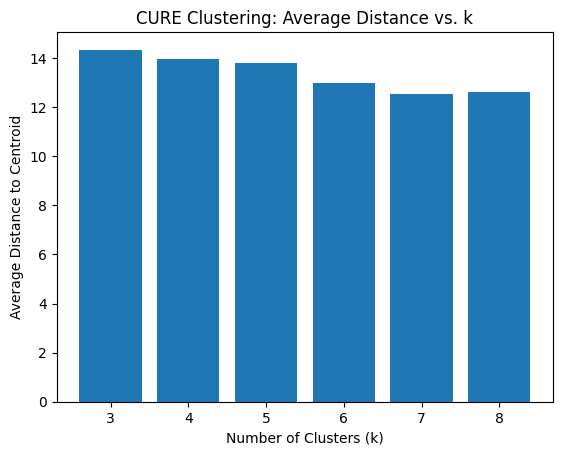

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import DenseVector, SparseVector, VectorUDT
from pyspark.sql import functions as F
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.types import DoubleType

class CUREClustering:
    def __init__(self, df, k_min=3, k_max=8, num_iterations=10):
        self.df = df
        self.k_min = k_min
        self.k_max = k_max
        self.num_iterations = num_iterations
        self.distances = []

    def fit(self):
        for k in range(self.k_min, self.k_max + 1):
            avg_distance = self._run_kmeans(k)
            self.distances.append(avg_distance)

    def _run_kmeans(self, k):
        # Apply KMeans clustering
        kmeans = KMeans(k=k, seed=1, featuresCol="embedding_vector", predictionCol="prediction")
        model = kmeans.fit(self.df)
        df_with_clusters = model.transform(self.df)

        # Calculate average distance from each point to the nearest representative
        avg_distance = self._calculate_avg_distance(df_with_clusters, model)
        return avg_distance

    def _calculate_avg_distance(self, df_with_clusters, model):
        # Centroids for each cluster
        centroids = model.clusterCenters()

        # Calculate distance from each point to its cluster centroid
        def compute_distance(vector, cluster_id):
            if vector is None:
                return float('inf')  # Handle null embeddings
            return float(np.linalg.norm(np.array(vector) - centroids[cluster_id]))

        compute_distance_udf = F.udf(compute_distance, DoubleType())

        # Add a column with distances to centroids
        df_with_clusters = df_with_clusters.withColumn(
            "distance_to_centroid",
            compute_distance_udf(F.col("embedding_vector"), F.col("prediction"))
        )

        # Compute the average distance
        avg_distance = df_with_clusters.select(F.mean("distance_to_centroid")).collect()[0][0]
        return avg_distance

    def plot_results(self):
        plt.bar(range(self.k_min, self.k_max + 1), self.distances)
        plt.xlabel("Number of Clusters (k)")
        plt.ylabel("Average Distance to Centroid")
        plt.title("CURE Clustering: Average Distance vs. k")
        plt.show()


# Prepare the embeddings for clustering
assembler = VectorAssembler(inputCols=["embedding"], outputCol="embedding_vector")
df_with_embeddings = assembler.transform(df_embedding_user)

# Initialize and run CURE clustering
cure = CUREClustering(df_with_embeddings, k_min=3, k_max=8)
cure.fit()

# Plot the results
cure.plot_results()
